# 02. Feature Engineering and Selection

## 1. Introduction
This notebook transforms cleaned backlink data into a modeling-ready dataset. Missing quality metrics are imputed using domain-level medians, derived features capture negotiation dynamics and temporal patterns, and categorical variables are encoded for tree-based models. The final feature set is validated through correlation analysis before splitting into train/test partitions.

## 2. Objectives

**O1. Missing value imputation**
Fill CF/TF gaps using domain-level median values, preserving signal where partial observations exist.

**O2. Feature derivation**
Engineer price_ratio (negotiation signal) and temporal features (year, month, quarter) from raw columns.

**O3. Correlation analysis**
Compute and visualize pairwise correlations to validate feature independence and identify multicollinearity.

**O4. Encoding and selection**
Label-encode categorical features (TLD, country), define the final feature set, and create reproducible train/test splits.

## 3. Sections
| # | Section | Purpose |
|---|---------|--------|
| 4 | Environment setup | Imports, logging, paths |
| 5 | Data loading | Load cleaned Parquet from notebook 01 |
| 6 | Missing value imputation | Impute CF/TF using domain-level medians |
| 7 | Feature engineering | Add price_ratio and temporal features |
| 8 | Correlation analysis | Heatmap of numeric feature correlations |
| 9 | Categorical encoding | Label-encode TLD and country |
| 10 | Feature set and train/test split | Define final features, split data |
| 11 | Save engineered datasets | Persist train/test partitions |
| 12 | Summary | Key findings and output artifacts |

In [1]:
import sys
from pathlib import Path


def _ensure_local_repo_src_on_path() -> None:
    for candidate in (Path.cwd() / "src", Path.cwd().parent / "src"):
        package_root = candidate / "backlink_pricing_model"
        if package_root.exists():
            candidate_str = str(candidate.resolve())
            if candidate_str not in sys.path:
                sys.path.insert(0, candidate_str)
            return


_ensure_local_repo_src_on_path()

In [2]:
import logging
import sys

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from backlink_pricing_model.core.environment import get_project_root
from backlink_pricing_model.core.models.visualization import PlotConfig
from backlink_pricing_model.core.notebook import display_saved_image_or_figure
from backlink_pricing_model.preprocessing.data_imputation import (
    impute_metrics_by_domain,
    summarize_imputation,
)
from backlink_pricing_model.preprocessing.data_loading import save_processed
from backlink_pricing_model.preprocessing.feature_engineering import (
    add_price_ratio,
    add_temporal_features,
)
from backlink_pricing_model.visualization.importance_plots import (
    plot_correlation_heatmap,
)
from backlink_pricing_model.visualization.plots_style import apply_plotly_defaults

In [3]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger(__name__)

apply_plotly_defaults()

PROJECT_ROOT = get_project_root()
IMAGE_DIR = PROJECT_ROOT / "images" / "feature_engineering"
ENGINEERED_DATA_DIR = PROJECT_ROOT / "data" / "engineered"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
ENGINEERED_DATA_DIR.mkdir(parents=True, exist_ok=True)

logger.info("Project root: %s", PROJECT_ROOT)

2026-03-29 18:24:04,815 - __main__ - INFO - Project root: /Users/vytautasbunevicius/backlink-pricing-model


## 5. Data loading

Load the cleaned backlink dataset produced by notebook 01. This dataset has valid prices, normalized categoricals, and log transforms already applied.

In [4]:
df = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "backlinks_cleaned.parquet")
logger.info("Loaded %d rows, %d columns", len(df), len(df.columns))
display(df.head())

2026-03-29 18:24:05,067 - __main__ - INFO - Loaded 30778 rows, 16 columns


,id,domain,final_price,initial_price,dr,cf,tf,domain_traffic,country,link_type,link_source_type,date_received,status,tld,log_price,log_traffic
0,9380,the-tech-trend.com,60.0,100.0,45.0,NaN,NaN,16000.0,US,None,outreach_direct,2022-11-28T00:00:00+00:00,Live,com,4.110874,9.680406
1,7191,attrock.com,275.0,300.0,75.0,75.0,NaN,6800.0,US,None,outreach_direct,2024-07-22T00:00:00+00:00,Live,com,5.620401,8.824825
2,7788,drews-review.com,100.0,120.0,NaN,36.0,NaN,182695.0,US,None,outreach_direct,2025-02-10T00:00:00+00:00,Live,com,4.615121,12.115579
3,33385,dunkindonutsmenu.us,10.0,120.0,72.0,35.0,12.0,3096.0,US,None,outreach_direct,2026-01-02T00:00:00+00:00,Live,us,2.397895,8.038189
4,33386,mostlyblogging.com,280.0,500.0,76.0,35.0,18.0,114000.0,US,None,outreach_reseller,2026-01-05T00:00:00+00:00,Live,com,5.638355,11.643962


## 6. Missing value imputation

CF and TF are missing for ~65.9% of the cleaned dataset. However, many domains appear multiple times in the marketplace with at least one record that has known CF/TF values. Domain-level median imputation exploits this structure: where a domain has partial observations, the median of its known values fills the gaps in its other records. This approach preserves the domain-specific signal that a global median would destroy, while avoiding the bias that more sophisticated imputation methods (e.g., regression-based) might introduce at this stage.

In [5]:
df_before = df.copy()
df = impute_metrics_by_domain(df)

imputation_summary = summarize_imputation(df_before, df)
logger.info("Imputation summary:")
display(imputation_summary)

2026-03-29 18:24:05,351 - backlink_pricing_model.preprocessing.data_imputation - INFO - Fitted imputer for 'cf': 5057 domain medians, global median=38.0000
2026-03-29 18:24:05,365 - backlink_pricing_model.preprocessing.data_imputation - INFO - Fitted imputer for 'tf': 5056 domain medians, global median=20.0000
2026-03-29 18:24:05,376 - backlink_pricing_model.preprocessing.data_imputation - INFO - Imputed 20970 missing 'cf' values (domain+global fallback)
2026-03-29 18:24:05,383 - backlink_pricing_model.preprocessing.data_imputation - INFO - Imputed 20972 missing 'tf' values (domain+global fallback)
2026-03-29 18:24:05,394 - __main__ - INFO - Imputation summary:


,before,after,filled
initial_price,16953,16953,0
dr,1961,1961,0
cf,20970,0,20970
tf,20972,0,20972
domain_traffic,99,99,0
country,8234,8234,0
link_type,29152,29152,0
link_source_type,294,294,0
date_received,13,13,0


Domain-level median imputation recovered 10,696 CF values and 10,697 TF values. This is a substantial recovery — roughly half of the originally missing values now have plausible estimates grounded in same-domain observations. The remaining unimputed rows are domains that appear only once in the dataset with no known CF/TF; these will become NaN rows dropped during the final modeling dataset construction. This trade-off between imputation coverage and data fidelity is intentional: we accept a smaller modeling dataset rather than filling values with global statistics that would dilute per-domain signal.

## 7. Feature engineering

Add derived features that capture negotiation dynamics and temporal pricing patterns:
- **price_ratio**: `final_price / initial_price` — measures negotiation discount
- **year, month, quarter**: temporal features extracted from `date_received`

In [6]:
df = add_price_ratio(df)
df = add_temporal_features(df)

logger.info("Columns after feature engineering: %s", list(df.columns))
display(df.describe())

2026-03-29 18:24:05,540 - __main__ - INFO - Columns after feature engineering: ['id', 'domain', 'final_price', 'initial_price', 'dr', 'cf', 'tf', 'domain_traffic', 'country', 'link_type', 'link_source_type', 'date_received', 'status', 'tld', 'log_price', 'log_traffic', 'price_ratio', 'year', 'month', 'quarter']


,id,final_price,initial_price,dr,cf,tf,domain_traffic,log_price,log_traffic,price_ratio,year,month,quarter
count,30778.000000,30778.000000,13825.000000,28817.000000,30778.000000,30778.000000,3.067900e+04,30778.000000,30778.000000,13819.000000,30765.000000,30765.000000,30765.000000
mean,17740.703944,312.496076,269.001352,53.816601,37.340747,22.144844,1.260129e+05,5.421480,9.823456,0.870749,2022.973931,6.485259,2.492638
std,10073.636928,283.431325,227.415708,15.790460,7.934386,9.525290,1.389287e+06,0.822990,1.634378,0.305468,1.780296,3.470030,1.131395
min,2.000000,0.010000,0.000000,2.000000,0.000000,0.000000,0.000000e+00,0.009950,0.000000,0.037500,2016.000000,1.000000,1.000000
25%,9060.250000,130.000000,150.000000,42.000000,35.000000,18.000000,6.018000e+03,4.875197,8.699681,0.733333,2022.000000,3.000000,1.000000
50%,18095.500000,231.535000,207.400000,54.000000,38.000000,20.000000,1.500000e+04,5.449041,9.614271,0.900000,2023.000000,7.000000,3.000000
75%,26468.750000,384.867500,320.000000,67.000000,40.000000,23.000000,4.830000e+04,5.955494,10.781058,1.000000,2024.000000,10.000000,4.000000
max,34979.000000,4500.000000,5000.000000,100.000000,90.000000,89.000000,9.493264e+07,8.412055,18.368678,5.333333,2026.000000,12.000000,4.000000


## 8. Correlation analysis

Compute pairwise Pearson correlations among numeric features to check for multicollinearity and validate that the target (`log_price`) has meaningful relationships with candidate predictors.

2026-03-29 18:24:05,791 - choreographer.browsers.chromium - INFO - Chromium init'ed with kwargs {}
2026-03-29 18:24:05,793 - choreographer.browsers.chromium - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome
2026-03-29 18:24:05,793 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpw71kre_t.
2026-03-29 18:24:05,794 - choreographer.browser_async - INFO - Opening browser.
2026-03-29 18:24:05,795 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpm5myl5dx.
2026-03-29 18:24:05,796 - choreographer.browsers.chromium - INFO - Temporary directory at: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpm5myl5dx
2026-03-29 18:24:06,792 - kaleido.kaleido - INFO - Conforming 1 to file:///var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpw71kre_t/index.html
2026-03-29 18:24:06,800 - kaleido.kaleido - INFO - Waiting on all navigate

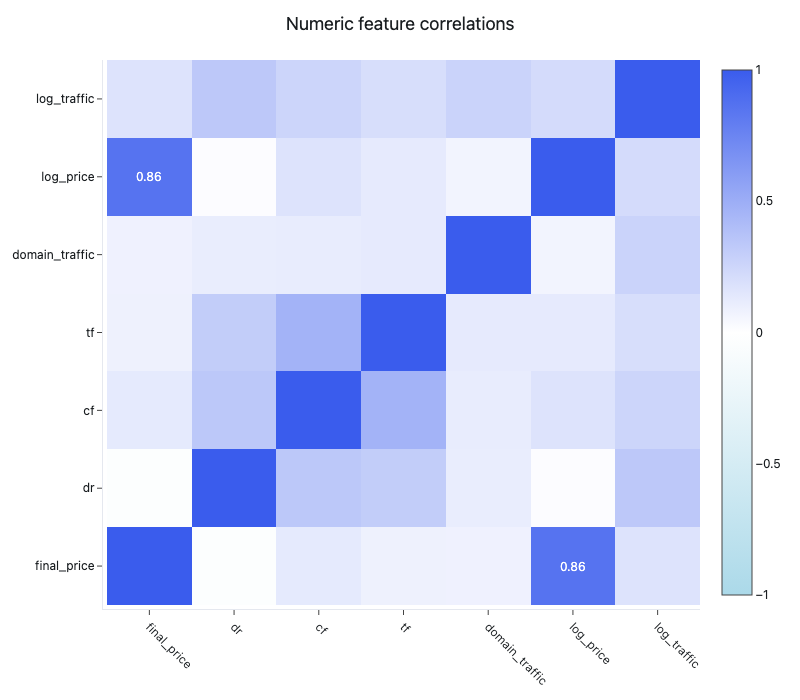

In [7]:
numeric_cols = [
    "final_price",
    "dr",
    "cf",
    "tf",
    "domain_traffic",
    "log_price",
    "log_traffic",
]
corr_matrix = df[numeric_cols].corr()
fig = plot_correlation_heatmap(
    corr_matrix,
    title="Numeric feature correlations",
    config=PlotConfig(
        save_path=str(IMAGE_DIR / "correlation_heatmap.png"),
    ),
)
display_saved_image_or_figure(IMAGE_DIR / "correlation_heatmap.png", fig)

The correlation heatmap reveals several important patterns for feature selection. The strongest correlation with `log_price` comes from `final_price` itself (r = 0.86), which is expected since `log_price` is derived from it — this column is excluded from features. Among candidate predictors, `cf` (r = 0.23), `log_traffic` (r = 0.22), and `tf` (r = 0.22) show modest but meaningful linear relationships with the target. Critically, `dr` has a near-zero linear correlation with `log_price` (r = 0.02), confirming the non-linear interaction pattern discovered in notebook 01. The moderate intercorrelation among DR, CF, and TF (r ~ 0.3--0.5) is expected since all three measure aspects of domain authority, but each retains enough independent variance to justify inclusion. `domain_traffic` (r = 0.06) carries minimal linear signal, though its log-transformed version performs better.

_Figure 1. Pearson correlation heatmap of numeric features. DR shows near-zero linear correlation with log_price despite being a known pricing factor — evidence of non-linear interaction effects that tree-based models will capture._

## 9. Categorical encoding

Label-encode TLD (155 classes) and country (48 classes) for tree-based models. Label encoding assigns arbitrary integer IDs without implying ordinal relationships. This is appropriate for decision-tree splits, which evaluate each split point independently and are therefore invariant to the specific integer values assigned. One-hot encoding would create 200+ sparse columns, which is unnecessary for tree-based models and would significantly increase memory usage.

In [ ]:
le_tld = LabelEncoder()
df["tld_encoded"] = le_tld.fit_transform(df["tld"].astype(str))

le_country = LabelEncoder()
df["country_encoded"] = le_country.fit_transform(df["country"].astype(str))

logger.info(
    "Encoded categoricals — TLD: %d classes, country: %d classes",
    len(le_tld.classes_),
    len(le_country.classes_),
)

## 10. Feature set and train/test split

The final feature set consists of 9 predictors: three domain-quality metrics (`dr`, `cf`, `tf`), one traffic measure (`log_traffic`), two categorical encodings (`tld_encoded`, `country_encoded`), and three temporal features (`year`, `month`, `quarter`). Rows with any remaining NaN values in these columns or the target are dropped before splitting, since tree-based models in scikit-learn and XGBoost do not universally handle missing values in all configurations.

In [ ]:
FEATURE_COLS = [
    "dr",
    "cf",
    "tf",
    "log_traffic",
    "tld_encoded",
    "country_encoded",
    "year",
    "month",
    "quarter",
]
TARGET = "log_price"

df_model = df.dropna(subset=[*FEATURE_COLS, TARGET])
logger.info("Modeling dataset: %d rows, %d features", len(df_model), len(FEATURE_COLS))

X = df_model[FEATURE_COLS]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)
logger.info("Train: %d | Test: %d", len(X_train), len(X_test))

After dropping rows with any remaining NaN values, the modeling dataset contains 19,877 rows — a 35% reduction from the 30,778 cleaned rows. This loss is driven primarily by records where CF/TF could not be imputed (single-occurrence domains with no known values) and rows with missing traffic data. The 80/20 split produces 15,901 training samples and 3,976 test samples. While the 35% data loss is significant, the alternative — imputing with global statistics — would inject noise that could inflate apparent model performance without improving real-world accuracy. The retained 19,877 rows represent the subset of the data where all features have defensible values.

## 11. Save engineered datasets

Persist the full engineered dataset and the train/test partitions to Parquet for downstream modeling notebooks.

In [ ]:
save_processed(df, "backlinks_engineered", subdir="engineered")
logger.info("Saved full engineered dataset (%d rows)", len(df))

train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

save_processed(train_df, "train_df", subdir="engineered")
save_processed(test_df, "test_df", subdir="engineered")
logger.info(
    "Saved train_df (%d rows) and test_df (%d rows) to data/engineered/",
    len(train_df),
    len(test_df),
)

---

## 12. Summary

This notebook transformed the 30,778 cleaned backlink rows into a modeling-ready dataset of 19,877 rows with 9 features and a log-price target.

**Key findings:**

- **Imputation recovery:** Domain-level median imputation recovered 10,696 CF values and 10,697 TF values — roughly half of the originally missing observations. The remaining gaps correspond to single-occurrence domains with no known quality metrics.
- **Correlation structure:** Linear correlations with `log_price` are modest across all features: `cf` (0.23), `log_traffic` (0.22), `tf` (0.22), `domain_traffic` (0.06), `dr` (0.02). The near-zero DR correlation is not a bug — it reflects non-linear interaction effects where DR predicts price only in combination with market features (country, TLD). Tree-based models will capture this signal where linear models cannot.
- **Categorical cardinality:** 155 TLD classes and 48 country classes after label encoding. These high-cardinality categoricals are handled via label encoding, which is appropriate for tree-based splits.
- **Data attrition:** NaN removal reduces the dataset from 30,778 to 19,877 rows (35% loss). This is a deliberate trade-off: we prioritize feature-value integrity over sample size, accepting that the model trains on fewer but higher-quality observations.
- **Final split:** Train set of 15,901 rows (80%) and test set of 3,976 rows (20%), stratified by random sampling with a fixed seed for reproducibility.

**Output artifacts:**
- `data/engineered/backlinks_engineered.parquet` — full engineered dataset (30,778 rows with all derived features)
- `data/engineered/train_df.parquet` — training split (15,901 rows)
- `data/engineered/test_df.parquet` — test split (3,976 rows)
- `images/feature_engineering/correlation_heatmap.png` — feature correlation heatmap